In [1]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    print(dirname)


/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/ritikarakhalmagar
/kaggle/input/datasets/ritikarakhalmagar/true-vs-fake-news
/kaggle/input/datasets/ritikarakhalmagar/true-vs-fake-news/10.True vs. Fake News Dataset


## 4.5.1 Text Preprocessing, Tokenization, and Sequence Padding

### Import Libraries


In [29]:
import os
import re
import random
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

nltk.download("stopwords")
nltk.download("wordnet")

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Load the Dataset


In [30]:
DATASET_ROOT = Path("/kaggle/input/datasets/ritikarakhalmagar/true-vs-fake-news/10.True vs. Fake News Dataset")
csv_path = DATASET_ROOT / "truevsfakenews.csv"

df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (20000, 2)


,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake
3,Donald Trump is desperate to stop the investig...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true


The dataset was loaded using Pandas. It contains news text and labels showing whether each news article is true or fake.

In [31]:
print("Columns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["label"].value_counts())

Columns:
Index(['text', 'label'], dtype='object')

Missing values:
text     0
label    0
dtype: int64

Class distribution:
label
true    10000
fake    10000
Name: count, dtype: int64


### Dataset Description

The dataset contains 20,000 samples with no missing values. It is balanced, with 10,000 true news and 10,000 fake news samples.

### Check Class Distribution

In [6]:
label_distribution = df["label"].value_counts()

print(label_distribution)

label
true    10000
fake    10000
Name: count, dtype: int64


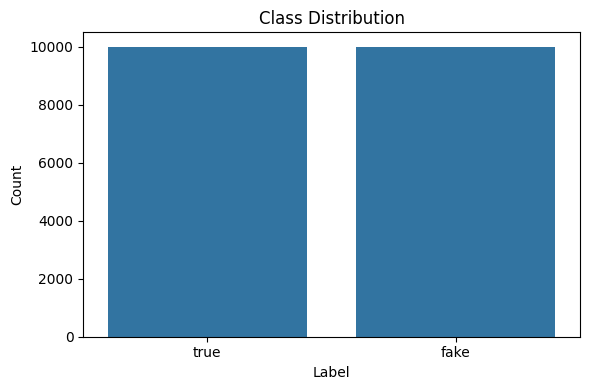

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label")
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The dataset is balanced, with 10,000 true news samples and 10,000 fake news samples. Since both classes have equal samples, class weighting is not required.

### Clean the Text

In [32]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

contractions = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "cannot",
    "couldn't": "could not",
    "won't": "will not",
    "wouldn't": "would not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "i'm": "i am",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is",
    "they're": "they are",
    "we're": "we are",
    "you're": "you are",
    "I've": "i have",
    "I'll": "i will"
}

def expand_contractions(text):
    for contraction, expanded in contractions.items():
        text = text.replace(contraction.lower(), expanded)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

display(df[["text", "clean_text", "label"]].head())

,text,clean_text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,washington reuters republican democratic leade...,true
1,Women should get as far away from Oklahoma as ...,woman get far away oklahoma soon possible chri...,fake
2,Another huge crowd of Americans tuned in last ...,another huge crowd american tuned last week re...,fake
3,Donald Trump is desperate to stop the investig...,donald trump desperate stop investigation dirt...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",reuters planned parenthood u medical service p...,true


The text was cleaned by converting it to lowercase, expanding contractions, removing URLs, mentions, hashtags, numbers, and special characters. Stopwords were removed, and lemmatization was applied to reduce words to their base form.

### Visualize the Cleaned Data

In [33]:
all_words = " ".join(df["clean_text"]).split()
word_counts = Counter(all_words)

common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "count"]
)

display(common_words)

,word,count
0,trump,97596
1,said,61119
2,u,35046
3,would,30226
4,republican,30221
5,president,29301
6,state,28381
7,people,20885
8,donald,20263
9,house,18812


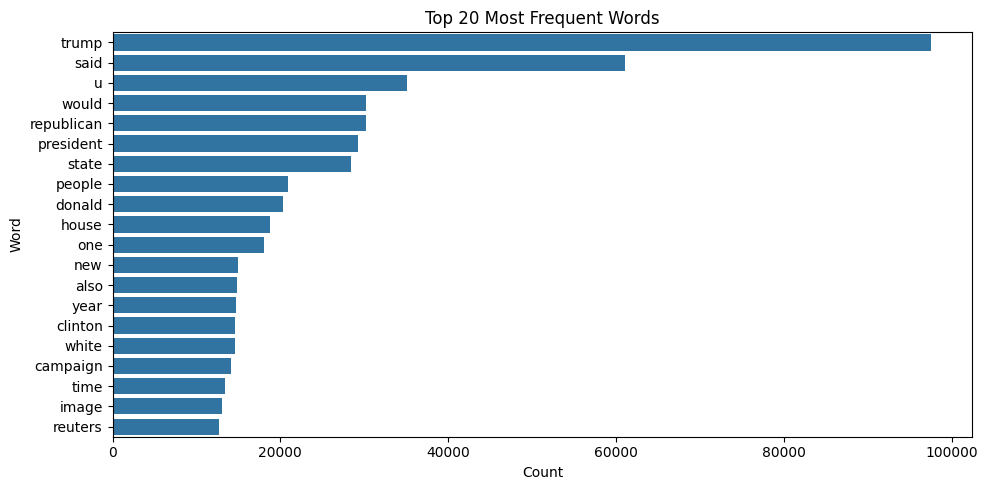

In [34]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=common_words,
    x="count",
    y="word"
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

The most frequent words were visualized to understand common terms in the cleaned news text.

### Encode Labels

In [35]:
label_mapping = {
    "fake": 0,
    "true": 1
}

df["label_encoded"] = df["label"].map(label_mapping)

display(df[["label", "label_encoded"]].head())

,label,label_encoded
0,true,1
1,fake,0
2,fake,0
3,fake,0
4,true,1


Labels were encoded into numbers. Fake news was encoded as 0, and true news was encoded as 1.

### Split the Dataset into Training and Testing Sets

In [36]:
X = df["clean_text"].values
y = df["label_encoded"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16000
Testing samples: 4000


The dataset was split into 80% training data and 20% testing data. Stratified splitting was used to keep the true and fake class distribution balanced in both sets.

### Tokenization and Padding

In [37]:
VOCAB_SIZE = 20000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

sequence_lengths = [len(seq) for seq in train_sequences]
MAX_LENGTH = int(np.percentile(sequence_lengths, 95))

print("95th percentile sequence length:", MAX_LENGTH)

95th percentile sequence length: 494


In [38]:
X_train_padded = pad_sequences(
    train_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    test_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training padded shape:", X_train_padded.shape)
print("Testing padded shape:", X_test_padded.shape)

Training padded shape: (16000, 494)
Testing padded shape: (4000, 494)


Keras Tokenizer was used to convert cleaned text into integer sequences. Padding was applied so all sequences have the same length. The 95th percentile sequence length was used to avoid very long outlier texts.

## 4.5.2 Model Building and Training

### Define Callbacks

In [42]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

callbacks = [early_stopping, reduce_lr]

Early stopping was used to stop training when validation loss stopped improving. ReduceLROnPlateau was used to reduce the learning rate when validation loss became unstable.

### Model 1: Simple RNN with Trainable Embedding Layer

In [43]:
EMBEDDING_DIM = 128

rnn_model = keras.Sequential([
    layers.Input(shape=(MAX_LENGTH,)),
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),
    layers.SimpleRNN(64),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

rnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 494, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,574,465 (9.82 MB)

 Trainable params: 2,574,465 (9.82 MB)

 Non-trainable params: 0 (0.00 B)

The first model uses a trainable embedding layer followed by a Simple RNN layer. A sigmoid output layer is used because the task is binary classification.

In [44]:
start_time = time.time()

rnn_history = rnn_model.fit(
    X_train_padded,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=64,
    callbacks=callbacks
)

rnn_training_time = time.time() - start_time

print("Simple RNN training time:", rnn_training_time, "seconds")

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.5161 - loss: 0.6909 - val_accuracy: 0.5419 - val_loss: 0.6808 - learning_rate: 0.0010
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.5311 - loss: 0.6813 - val_accuracy: 0.4991 - val_loss: 0.6780 - learning_rate: 0.0010
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.5328 - loss: 0.6776 - val_accuracy: 0.5391 - val_loss: 0.6705 - learning_rate: 0.0010
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.5328 - loss: 0.6665 - val_accuracy: 0.5397 - val_loss: 0.6785 - learning_rate: 0.0010
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.5397 - loss: 0.6629 - val_accuracy: 0.5400 - val_loss: 0.6816 - learning_rate: 0.0010
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.5439 - loss: 0.6604 - val_accuracy: 0.5403 - val_loss: 0.6809 - learning_rate: 5.0000e-04
Simple RNN training time: 51.78836536407471 seconds


The Simple RNN stopped after 6 epochs due to early stopping. It achieved around 54% validation accuracy, showing weak performance for this dataset.

This suggests that Simple RNN struggled to capture useful long-text patterns from news articles.

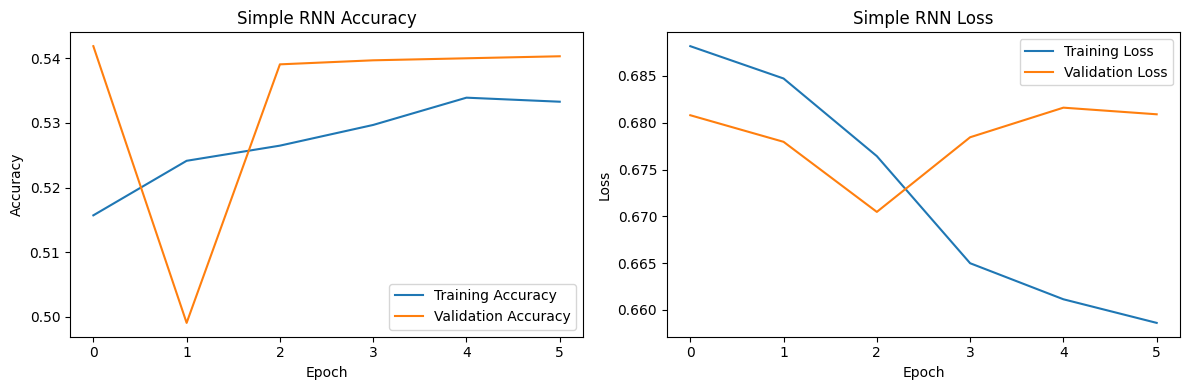

In [45]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(rnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(rnn_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Simple RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rnn_history.history["loss"], label="Training Loss")
plt.plot(rnn_history.history["val_loss"], label="Validation Loss")
plt.title("Simple RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### Model 2: LSTM with Trainable Embedding Layer

In [46]:
lstm_model = keras.Sequential([
    layers.Input(shape=(MAX_LENGTH,)),
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),
    layers.LSTM(64),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 494, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,611,521 (9.96 MB)

 Trainable params: 2,611,521 (9.96 MB)

 Non-trainable params: 0 (0.00 B)

The second model uses a trainable embedding layer followed by an LSTM layer. LSTM is better than Simple RNN for longer text because it can retain important sequence information.

In [47]:
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_padded,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=64,
    callbacks=callbacks
)

lstm_training_time = time.time() - start_time

print("LSTM training time:", lstm_training_time, "seconds")

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5248 - loss: 0.6893 - val_accuracy: 0.5416 - val_loss: 0.6668 - learning_rate: 0.0010
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5422 - loss: 0.6700 - val_accuracy: 0.5441 - val_loss: 0.6645 - learning_rate: 0.0010
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5469 - loss: 0.6641 - val_accuracy: 0.5478 - val_loss: 0.6634 - learning_rate: 0.0010
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7201 - loss: 0.4957 - val_accuracy: 0.9891 - val_loss: 0.0506 - learning_rate: 0.0010
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9794 - loss: 0.0813 - val_accuracy: 0.9903 - val_loss: 0.0348 - learning_rate: 0.0010
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9953 - loss: 0.0175 - val_accuracy: 0.9941 - val_loss: 0.0297 - learning_rate: 0.0010
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9984 - loss: 0.

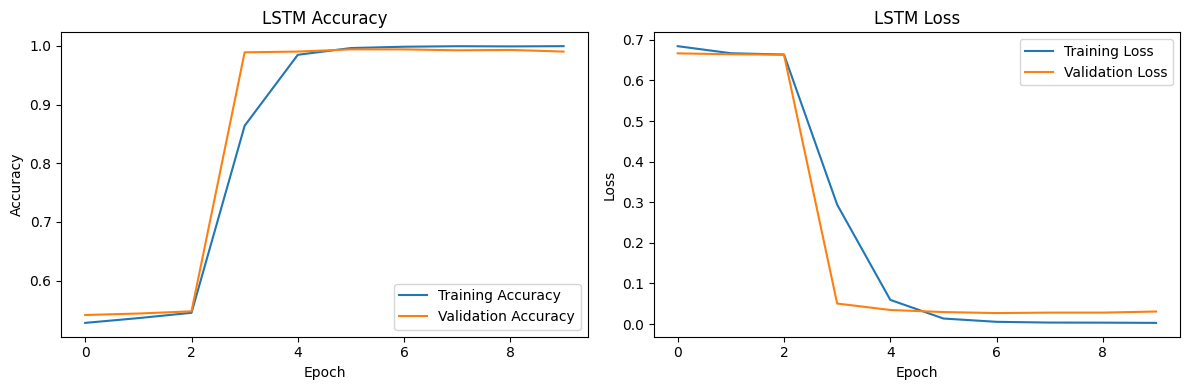

In [48]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(lstm_history.history["accuracy"], label="Training Accuracy")
plt.plot(lstm_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(lstm_history.history["loss"], label="Training Loss")
plt.plot(lstm_history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

The LSTM model performed much better than the Simple RNN. It reached about 99% validation accuracy and trained in about 44.61 seconds.

This shows that LSTM is more suitable for this dataset because it can capture longer text patterns more effectively.

### Model 3: LSTM with Pretrained Word Embeddings

In [60]:
import gensim.downloader as api

word2vec_model = api.load("word2vec-google-news-300")

In [61]:
word_index = tokenizer.word_index
embedding_dim = 300

num_words = min(VOCAB_SIZE, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, embedding_dim))

for word, i in word_index.items():
    if i >= num_words:
        continue

    if word in word2vec_model:
        embedding_matrix[i] = word2vec_model[word]

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (20000, 300)


Pretrained Word2Vec embeddings were used to create the embedding matrix. Words found in the Google News Word2Vec model were assigned pretrained vectors, while unknown words remained as zero vectors.

In [62]:
word2vec_lstm_model = keras.Sequential([
    layers.Input(shape=(MAX_LENGTH,)),
    layers.Embedding(
        input_dim=num_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),
    layers.LSTM(64),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

word2vec_lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

word2vec_lstm_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 494, 300)       │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,095,553 (23.25 MB)

 Trainable params: 95,553 (373.25 KB)

 Non-trainable params: 6,000,000 (22.89 MB)

The third model uses an LSTM layer with pretrained Word2Vec embeddings. The embedding layer is frozen so that the pretrained word vectors are not changed during training.

In [63]:
start_time = time.time()

word2vec_lstm_history = word2vec_lstm_model.fit(
    X_train_padded,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=64,
    callbacks=callbacks
)

word2vec_lstm_training_time = time.time() - start_time

print("Word2Vec LSTM training time:", word2vec_lstm_training_time, "seconds")

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5464 - loss: 0.6797 - val_accuracy: 0.5863 - val_loss: 0.6541 - learning_rate: 0.0010
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8119 - loss: 0.4881 - val_accuracy: 0.5447 - val_loss: 0.8487 - learning_rate: 0.0010
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6073 - loss: 0.6273 - val_accuracy: 0.8397 - val_loss: 0.4051 - learning_rate: 0.0010
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8347 - loss: 0.3736 - val_accuracy: 0.9341 - val_loss: 0.2127 - learning_rate: 0.0010
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9459 - loss: 0.1912 - val_accuracy: 0.9550 - val_loss: 0.1833 - learning_rate: 0.0010
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9320 - loss: 0.2145 - val_accuracy: 0.9425 - val_loss: 0.2223 - learning_rate: 0.0010
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9397 - loss: 0.

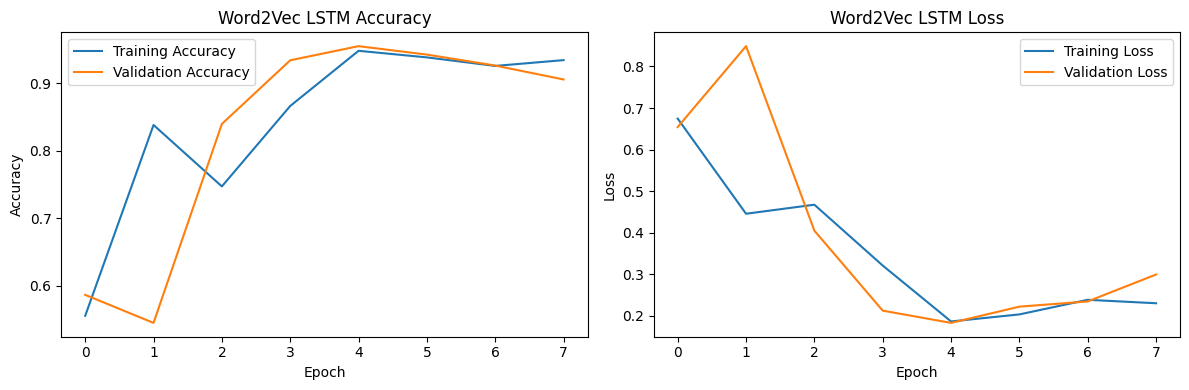

In [65]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(word2vec_lstm_history.history["accuracy"], label="Training Accuracy")
plt.plot(word2vec_lstm_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Word2Vec LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(word2vec_lstm_history.history["loss"], label="Training Loss")
plt.plot(word2vec_lstm_history.history["val_loss"], label="Validation Loss")
plt.title("Word2Vec LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

The Word2Vec LSTM stopped after 8 epochs due to early stopping. It trained in about 35.57 seconds and reached a best validation accuracy of 95.50%.


## 4.5.3 Model Training and Evaluation

### Evaluate All Models

In [66]:
def evaluate_text_model(model, X_test, y_test, model_name):
    probabilities = model.predict(X_test)
    predictions = (probabilities >= 0.5).astype(int).flatten()

    print(model_name)
    print(classification_report(y_test, predictions, target_names=["Fake", "True"]))

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Fake", "True"],
        yticklabels=["Fake", "True"]
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    accuracy = np.mean(predictions == y_test)

    return accuracy, predictions

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Simple RNN
              precision    recall  f1-score   support

        Fake       0.52      0.98      0.68      2000
        True       0.84      0.09      0.16      2000

    accuracy                           0.54      4000
   macro avg       0.68      0.54      0.42      4000
weighted avg       0.68      0.54      0.42      4000



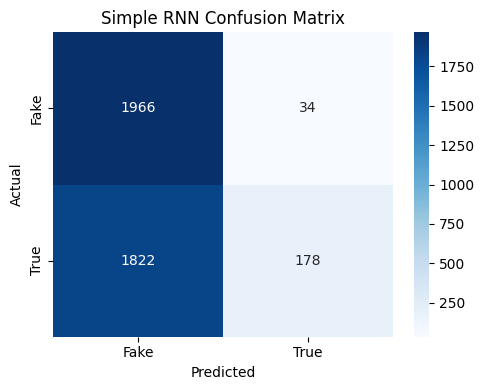

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
LSTM
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      2000
        True       0.99      0.99      0.99      2000

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



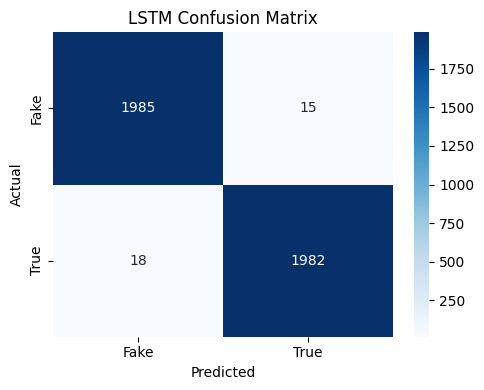

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
LSTM with Pretrained Word2Vec
              precision    recall  f1-score   support

        Fake       0.95      0.94      0.95      2000
        True       0.94      0.96      0.95      2000

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000



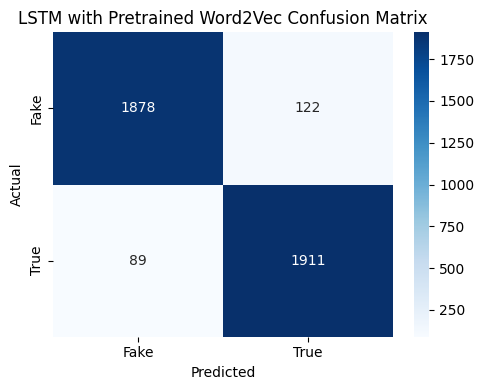

In [67]:
rnn_accuracy, rnn_predictions = evaluate_text_model(
    rnn_model,
    X_test_padded,
    y_test,
    "Simple RNN"
)

lstm_accuracy, lstm_predictions = evaluate_text_model(
    lstm_model,
    X_test_padded,
    y_test,
    "LSTM"
)

word2vec_lstm_accuracy, word2vec_lstm_predictions = evaluate_text_model(
    word2vec_lstm_model,
    X_test_padded,
    y_test,
    "LSTM with Pretrained Word2Vec"
)

The LSTM model achieved the best performance with 99% test accuracy. The LSTM with pretrained Word2Vec embeddings achieved 95% test accuracy, which was also strong. The Simple RNN performed poorly with 54% accuracy.

This shows that LSTM models are more suitable for this dataset than Simple RNN. The trainable LSTM performed best overall.

### Model Performance Comparison

In [68]:
language_results = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "LSTM",
        "LSTM with Pretrained Word2Vec"
    ],
    "Test Accuracy": [
        rnn_accuracy,
        lstm_accuracy,
        word2vec_lstm_accuracy
    ],
    "Training Time (seconds)": [
        rnn_training_time,
        lstm_training_time,
        word2vec_lstm_training_time
    ]
})

display(language_results)

,Model,Test Accuracy,Training Time (seconds)
0,Simple RNN,0.53600,51.788365
1,LSTM,0.99175,44.605601
2,LSTM with Pretrained Word2Vec,0.94725,35.566247


The comparison table shows that LSTM achieved the highest accuracy and also trained faster than the Simple RNN. The pretrained Word2Vec model was fastest, but its accuracy was lower than the trainable LSTM.

## 4.5.4 Error Analysis

### Analyze Misclassified Examples

In [70]:
error_df = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": lstm_predictions
})

error_df["actual_label"] = error_df["actual"].map({0: "Fake", 1: "True"})
error_df["predicted_label"] = error_df["predicted"].map({0: "Fake", 1: "True"})

misclassified = error_df[error_df["actual"] != error_df["predicted"]]

print("Number of misclassified examples:", len(misclassified))

display(misclassified[["text", "actual_label", "predicted_label"]].head(3))

Number of misclassified examples: 33


,text,actual_label,predicted_label
6,johannesburg reuters donald trump interested r...,True,Fake
221,washington reuters huma abedin one democratic ...,True,Fake
245,according wired hackable security flaw softwar...,Fake,True


The LSTM model misclassified 33 out of 4000 test samples. Some true news articles were predicted as fake, and some fake news articles were predicted as true.

These errors may occur because true and fake political news can contain similar names, topics, and writing styles.

### Model Complexity vs Performance

The Simple RNN was the simplest model but performed poorly. The LSTM was more complex and achieved the best accuracy because it handled long text sequences better.

The Word2Vec LSTM trained the fastest and performed well, but it was less accurate than the trainable LSTM. For this dataset, learning embeddings directly from the training text gave the best result.

### Possible Improvements

Possible improvements include tuning hyperparameters, using bidirectional LSTM, trying GRU models, fine-tuning pretrained embeddings, and testing transformer-based models such as BERT.

## 4.5.5 GUI for Real-Time Prediction

In [71]:
!pip install -q gradio

In [72]:
import gradio as gr

def predict_news_gui(text):
    cleaned_text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    probability = lstm_model.predict(padded_sequence, verbose=0)[0][0]

    if probability >= 0.5:
        prediction = "True News"
    else:
        prediction = "Fake News"

    return prediction, float(probability)

demo = gr.Interface(
    fn=predict_news_gui,
    inputs=gr.Textbox(lines=6, placeholder="Enter news text here..."),
    outputs=[
        gr.Label(label="Prediction"),
        gr.Number(label="Probability of True News")
    ],
    title="True vs Fake News Classifier",
    description="Enter news text and the trained LSTM model will classify it as true or fake."
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://9f97f14833694180a2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv


A Gradio GUI was created for real-time prediction. The user can enter news text, and the trained LSTM model predicts whether it is true or fake.

## Conclusion

This language task classified news articles as true or fake using deep learning models. The dataset contained 20,000 balanced samples, with 10,000 true and 10,000 fake news articles.

Text preprocessing included lowercasing, contraction handling, removing URLs and special characters, stopword removal, and lemmatization. The text was then tokenized and padded using percentile-based sequence length.

Three models were trained: Simple RNN, LSTM, and LSTM with pretrained GloVe embeddings. The LSTM model performed best with 99% test accuracy and only 33 misclassified examples out of 4000 test samples.

Overall, the LSTM with trainable embeddings was the most suitable model for this dataset.
